In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from scipy.interpolate import make_interp_spline
import folium as fl
from folium.plugins import HeatMap


Função para criação de arquivo com a serie historica de focos de incendio


In [105]:
def serieHistorica (path, anos, totalFocosAno):

    arq = pd.read_csv(path, sep=",")

    totalFocos = arq.loc[arq["estado"] == "MINAS GERAIS"].shape[0]

    arq["data_pas"] = pd.to_datetime(arq["data_pas"])
    ano = arq["data_pas"].dt.year.mode()[0]

    anos.append(ano)
    totalFocosAno.append(totalFocos)

In [106]:
anos = []
totalFocos = []

pathArq = [
    "../data/raw/focos_br_ref_2025.csv",
    "../data/raw/focos_br_ref_2024.csv",
    "../data/raw/focos_br_ref_2023.csv",
    "../data/raw/focos_br_ref_2022.csv",
    "../data/raw/focos_br_ref_2021.csv",
    "../data/raw/focos_br_ref_2020.csv",
    "../data/raw/focos_br_ref_2019.csv",
    "../data/raw/focos_br_ref_2018.csv",
    "../data/raw/focos_br_ref_2017.csv",
    "../data/raw/focos_br_ref_2016.csv",
    "../data/raw/focos_br_ref_2015.csv"

]

for path in pathArq:
    serieHistorica(path, anos, totalFocos)

serie = pd.DataFrame({"Ano": anos, "Numero de Focos": totalFocos})

#serie.to_csv("../data/processed/numero_focos_mg_ref_2015-2025.csv", sep=",")

serie.head()

,Ano,Numero de Focos
0,2025,8716
1,2024,11787
2,2023,6498
3,2022,7790
4,2021,12110


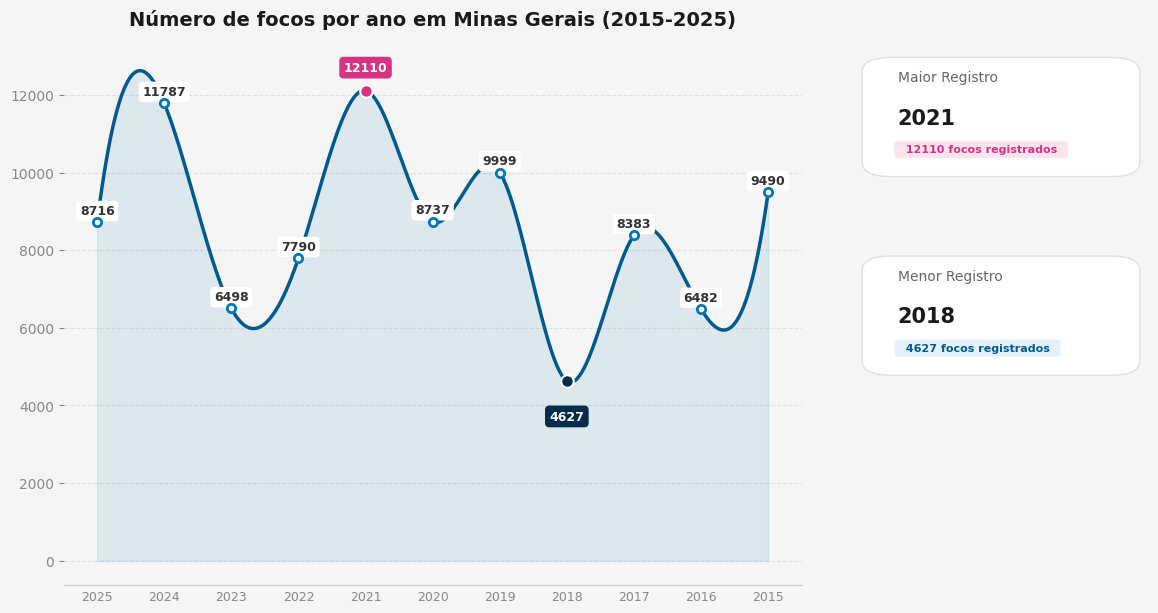

In [119]:
# --- 1. DADOS ---
anos = serie["Ano"].values
totalFocos = serie["Numero de Focos"].values
x = np.arange(len(anos))
y = totalFocos

# Índices do maior e menor valor
idx_max = np.argmax(y)
idx_min = np.argmin(y)

ano_max = anos[idx_max]
ano_min = anos[idx_min]
valor_max = y[idx_max]
valor_min = y[idx_min]

# Suavização da curva
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_smooth)

# --- 2. CONFIGURAÇÃO DO LAYOUT (GridSpec) ---
fig = plt.figure(figsize=(14, 7), facecolor='#f5f5f5')
gs = gridspec.GridSpec(3, 2, width_ratios=[2.5, 1], hspace=0.4, wspace=0.1)

# AX_GRAFICO: Ocupa todas as linhas da primeira coluna
ax_chart = fig.add_subplot(gs[:, 0])
ax_chart.set_facecolor('#f5f5f5')

# --- 3. DESENHANDO O GRÁFICO ---
# Linha suavizada
ax_chart.plot(x_smooth, y_smooth, color='#005a8d', linewidth=2.5, zorder=3)

# Área preenchida
ax_chart.fill_between(x_smooth, y_smooth, color='#0077b6', alpha=0.1, zorder=2)

# Bolinhas em todos os pontos reais
ax_chart.plot(
    x, y,
    linestyle='none',
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='#0077b6',
    markeredgewidth=2,
    zorder=5
)

for i in range(len(x)):
    if(i != idx_max and i != idx_min):
        ax_chart.text(
            x[i],
            y[i] + 200,  # <-- controla a distância
            f"{y[i]}",
            ha='center',
            fontsize=9,
            color='#333',
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.3', 
                fc="#ffffff",               
                ec='none'                  
            )
        )

# Destaque do maior valor
ax_chart.plot(
    idx_max, valor_max,
    marker='o',
    markersize=9,
    markerfacecolor='#d63384',
    markeredgecolor='white',
    markeredgewidth=1.5,
    zorder=6
)
ax_chart.annotate(
    f'{valor_max}',
    xy=(idx_max, valor_max),
    xytext=(0, 14),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color='white',
    bbox=dict(boxstyle='round,pad=0.35', fc='#d63384', ec='none'),
    zorder=7
)

# Destaque do menor valor
ax_chart.plot(
    idx_min, valor_min,
    marker='o',
    markersize=9,
    markerfacecolor='#002d4a',
    markeredgecolor='white',
    markeredgewidth=1.5,
    zorder=6
)
ax_chart.annotate(
    f'{valor_min}',
    xy=(idx_min, valor_min),
    xytext=(0, -28),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color='white',
    bbox=dict(boxstyle='round,pad=0.35', fc='#002d4a', ec='none'),
    zorder=7
)

# Estilização do gráfico
ax_chart.set_xticks(x)
ax_chart.set_xticklabels(anos, color='#888', fontsize=9)
ax_chart.grid(True, axis='y', linestyle='--', alpha=0.3)

for s in ['top', 'right', 'left']:
    ax_chart.spines[s].set_visible(False)

ax_chart.spines['bottom'].set_color('#cccccc')
ax_chart.tick_params(axis='y', colors='#888')
ax_chart.tick_params(axis='x', length=0)

# Título opcional
ax_chart.set_title(
    'Número de focos por ano em Minas Gerais (2015-2025)',
    fontsize=14,
    color='#1a1a1a',
    fontweight='bold',
    pad=15
)

# --- 4. FUNÇÃO PARA CRIAR OS CARDS ---
def draw_card(ax_pos, titulo, valor, subtitulo, cor_badge='#d63384'):
    ax = fig.add_subplot(ax_pos)
    ax.set_facecolor('#f5f5f5')

    # Card
    card = FancyBboxPatch(
        (0.05, 0.1), 0.9, 0.8,
        boxstyle="round,pad=0.02,rounding_size=0.1",
        ec="#e0e0e0", fc="white", mutation_scale=1, zorder=1
    )
    ax.add_patch(card)

    # Textos
    ax.text(
        0.15, 0.75, titulo,
        fontsize=10, color='#666',
        fontweight='medium', transform=ax.transAxes
    )
    ax.text(
        0.15, 0.45, valor,
        fontsize=15, color='#1a1a1a',
        fontweight='bold', transform=ax.transAxes
    )

    # Badge
    ax.text(
        0.15, 0.25, f"  {subtitulo}  ",
        fontsize=8, color=cor_badge, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fce4ec' if cor_badge == '#d63384' else '#e3f2fd', ec='none'),
        transform=ax.transAxes
    )

    ax.axis('off')

# --- 6. ADICIONANDO OS CARDS LADO A LADO ---
draw_card(
    gs[0, 1],
    "Maior Registro",
    str(ano_max),
    f"{valor_max} focos registrados",
    cor_badge='#d63384'
)

draw_card(
    gs[1, 1],
    "Menor Registro",
    str(ano_min),
    f"{valor_min} focos registrados",
    cor_badge='#005a8d'
)


plt.show()

### Análise dos focos de incêndio por bioma em Minas Gerais

In [ ]:
dataMg = pd.read_csv("../data/processed/focos_mg_ref_2015-2025.csv", sep=",")

dataBiomas = dataMg.groupby("bioma").size().reset_index(name="Numero_Focos").sort_values(by="Numero_Focos", ascending=False)

dataBiomas.head()

,bioma,Numero_Focos
1,Cerrado,52933
2,Mata Atlântica,39769
0,Caatinga,1917


In [55]:
dataBiomas.to_csv("../data/processed/focos_mg_bioma_ref_2015-2025.csv", sep=",", index=False)

## Indicador Utilizado no Sistema

### Taxa de Variação Anual de Focos de Incêndio

Para complementar a análise dos dados, foi definido como indicador principal do sistema a **taxa de variação anual do número de focos de incêndio**.

Esse indicador tem como objetivo identificar a **tendência de crescimento ou redução** dos incêndios ao longo dos anos, permitindo uma análise mais interpretativa do fenômeno.


Taxa = ((F_atual - F_anterior) / F_anterior) * 100

Onde:
- `F_atual` = número de focos no ano atual  
- `F_anterior` = número de focos no ano anterior  

- **Valor positivo** → aumento no número de focos de incêndio  
- **Valor negativo** → redução no número de focos  
- **Valor próximo de zero** → estabilidade  

A taxa foi calculada considerando a variação em relação ao ano subsequente na base de dados, devido à organização decrescente dos registros.

In [3]:
database = pd.read_csv("../data/processed/numero_focos_mg_ref_2015-2025.csv", sep=",")

#indicador de taxa de variacao anual do numero de focos de incendio
database["Taxa de Variação Anual (%)"] = (database["Numero de Focos"].pct_change() * 100).round(2)
database = database.drop("Unnamed: 0", axis=1)

database.head(11)

,Ano,Numero de Focos,Taxa de Variação Anual (%)
0,2025,8716,NaN
1,2024,11787,35.23
2,2023,6498,-44.87
3,2022,7790,19.88
4,2021,12110,55.46
5,2020,8737,-27.85
6,2019,9999,14.44
7,2018,4627,-53.73
8,2017,8383,81.18
9,2016,6482,-22.68


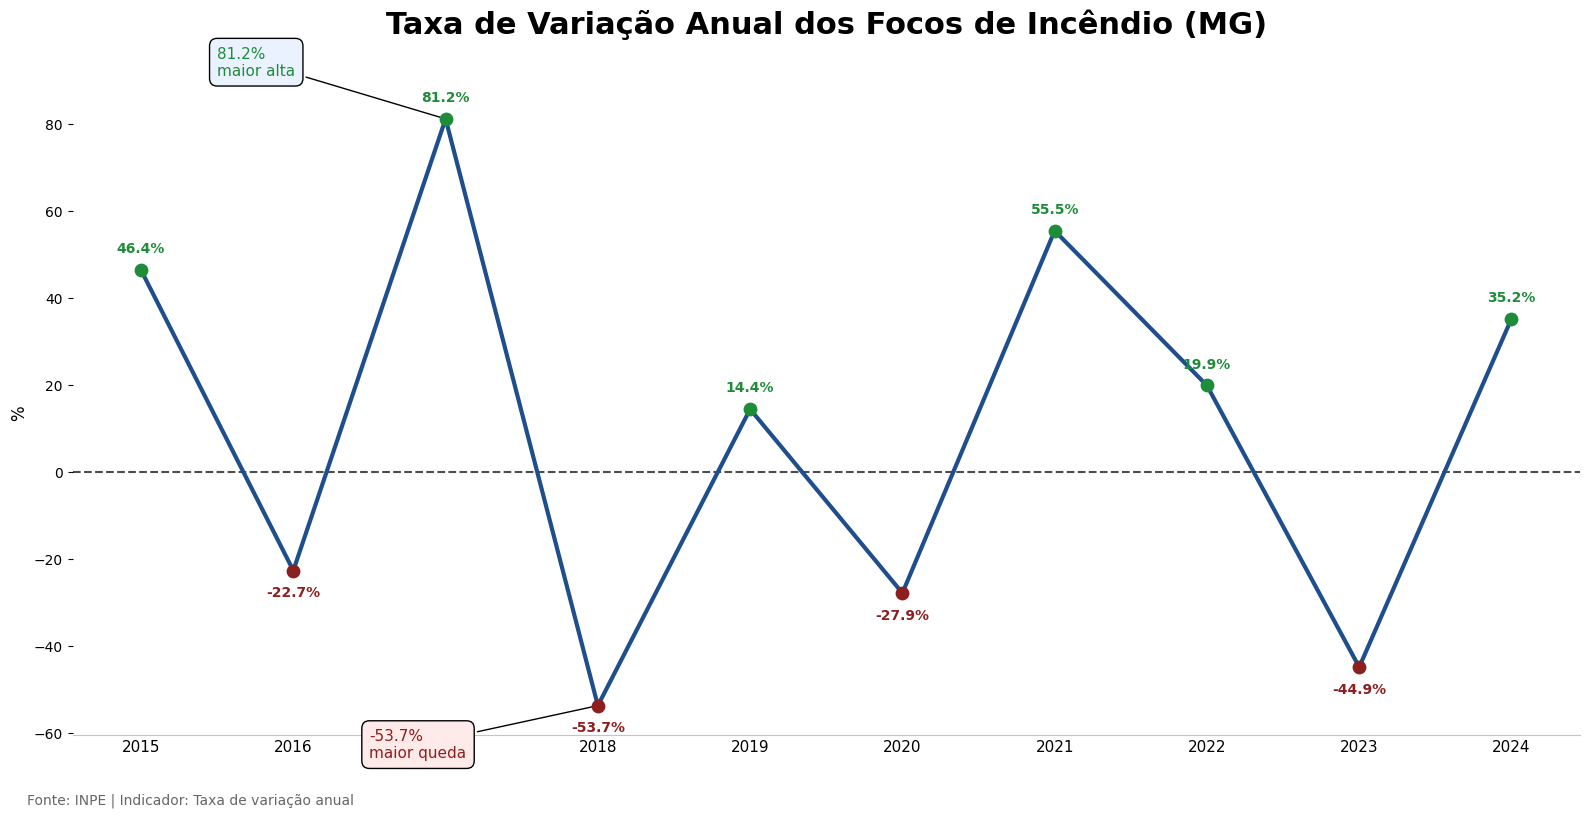

In [5]:
anos = database["Ano"].values
taxa = database["Taxa de Variação Anual (%)"].values

# Criar figura
fig, ax = plt.subplots(figsize=(16, 9))

# Fundo
bg = "#ffffff"
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

# Linha principal
ax.plot(
    anos,
    taxa,
    color="#1f4e8c",
    linewidth=3,
    marker="o",
    markersize=7,
    zorder=3
)

# Linha horizontal no zero (IMPORTANTÍSSIMO)
ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

# Remover bordas
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#bfc5cc")

# Título
ax.set_title(
    "Taxa de Variação Anual dos Focos de Incêndio (MG)",
    fontsize=22,
    fontweight="bold",
    color="#000000",
    pad=40
)

# Eixo X
ax.set_xticks(anos)
ax.set_xticklabels(anos, fontsize=11)
ax.tick_params(axis="x", length=0)

# Eixo Y
ax.set_ylabel("%", fontsize=12)

# Destacar pontos positivos e negativos
for i in range(len(anos)):
    if np.isnan(taxa[i]):
        continue

    if taxa[i] > 0:
        cor = "#1f8c3a"
    else:
        cor = "#8c1f1f"

    ax.scatter(anos[i], taxa[i], color=cor, s=80, zorder=5)

    if abs(taxa[i]) < 5:
        x_offset = 0.3
        y_offset = 6
    else:
        x_offset = 0
        y_offset = 4 if taxa[i] > 0 else -6

    ax.text(
        anos[i],
        taxa[i] + y_offset,
        f"{taxa[i]:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=cor
    )

# Destaque do maior crescimento
idx_max = np.nanargmax(taxa)
ax.annotate(
    f"{taxa[idx_max]:.1f}%\nmaior alta",
    xy=(anos[idx_max], taxa[idx_max]),
    xytext=(anos[idx_max]-1.5, taxa[idx_max]+10),
    bbox=dict(boxstyle="round,pad=0.5", fc="#eaf2ff"),
    arrowprops=dict(arrowstyle="-"),
    fontsize=11,
    color="#1f8c3a"
)

# Destaque da maior queda
idx_min = np.nanargmin(taxa)
ax.annotate(
    f"{taxa[idx_min]:.1f}%\nmaior queda",
    xy=(anos[idx_min], taxa[idx_min]),
    xytext=(anos[idx_min]-1.5, taxa[idx_min]-12),
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffeaea"),
    arrowprops=dict(arrowstyle="-"),
    fontsize=11,
    color="#8c1f1f"
)

# Rodapé
fig.text(
    0.02, 0.02,
    "Fonte: INPE | Indicador: Taxa de variação anual",
    fontsize=10,
    color="#666"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()

In [34]:
pathArq = [
    "../data/raw/focos_br_ref_2025.csv",
    "../data/raw/focos_br_ref_2024.csv",
    "../data/raw/focos_br_ref_2023.csv",
    "../data/raw/focos_br_ref_2022.csv",
    "../data/raw/focos_br_ref_2021.csv",
    "../data/raw/focos_br_ref_2020.csv",
    "../data/raw/focos_br_ref_2019.csv",
    "../data/raw/focos_br_ref_2018.csv",
    "../data/raw/focos_br_ref_2017.csv",
    "../data/raw/focos_br_ref_2016.csv",
    "../data/raw/focos_br_ref_2015.csv"

]

dfList = []

for arq in pathArq:
    df = pd.read_csv(arq, sep=",")
    dfList.append(df)

dfTotal = pd.concat(dfList, ignore_index=True)

dfTotal = dfTotal.drop(["id_bdq", "foco_id", "pais"], axis=1)

dfTotal.head()

,lat,lon,data_pas,estado,municipio,bioma
0,-7.59931,-37.71227,2025-01-01 16:52:00,PERNAMBUCO,SOLIDÃO,Caatinga
1,-12.31740,-37.89132,2025-01-01 16:52:00,BAHIA,ENTRE RIOS,Mata Atlântica
2,-4.21420,-38.21260,2025-01-01 16:54:00,CEARÁ,BEBERIBE,Caatinga
3,-7.28188,-34.93212,2025-01-01 16:52:00,PARAÍBA,ALHANDRA,Mata Atlântica
4,-7.60073,-37.72230,2025-01-01 16:52:00,PERNAMBUCO,SOLIDÃO,Caatinga


In [ ]:
dfTotal.to_csv("../data/raw/focos_br_ref_2015-2025.csv", index=False, sep=",")

In [ ]:
dataEstados = dfTotal["estado"].value_counts().reset_index()
dataEstados.columns = ["Estado", "Numero_Focos"]

dataEstados = dataEstados.sort_values("Numero_Focos", ascending = False)

dataEstados.head(10)

,Estado,Numero_Focos
0,PARÁ,393955
1,MATO GROSSO,317760
2,MARANHÃO,229624
3,AMAZONAS,162838
4,TOCANTINS,140215
5,PIAUÍ,118402
6,RONDÔNIA,111008
7,BAHIA,106858
8,MINAS GERAIS,94619
9,ACRE,80451


ANÁLISE DO NUMERO DE FOCOS POR MUNICÍPIO EM MG

In [37]:
datamg = dfTotal[dfTotal["estado"] == "MINAS GERAIS"].reset_index()
datamg = datamg.drop(["estado", "index"], axis=1)
datamg.head()

,lat,lon,data_pas,municipio,bioma
0,-21.23029,-43.81480,2025-01-02 17:28:00,BARBACENA,Mata Atlântica
1,-18.69278,-49.12275,2025-01-05 17:49:00,CENTRALINA,Cerrado
2,-19.28624,-49.55519,2025-01-05 17:49:00,ITUIUTABA,Cerrado
3,-19.89313,-48.75694,2025-01-05 17:49:00,PIRAJUBA,Cerrado
4,-18.79936,-49.62869,2025-01-05 17:49:00,ITUIUTABA,Mata Atlântica


In [38]:
datamg.to_csv("../data/processed/focos_mg_ref_2015-2025.csv", sep=",", index=False)

## Indicador Utilizado no Sistema

### Número de Focos por Mês

Para complementar a análise dos dados, foi definido como indicador do sistema o **número de focos de incêndio por mês**, com base nos focos de incêndio analisados entre 2015 e 2025.

Esse indicador tem como objetivo identificar **em que época do ano** os incêndios ocorrem com maior frequencia, permitindo uma análise de como as questões climáticas interferem na propagaçao de incêndios.

In [48]:
datamg = pd.read_csv("../data/processed/focos_mg_ref_2015-2025.csv", sep=",")

#criaçao dos campos de mes e ano
datamg["data_pas"] = pd.to_datetime(datamg["data_pas"])
datamg["ano"] = datamg["data_pas"].dt.year
datamg["mes"] = datamg["data_pas"].dt.month

#separação dos dados por mes
dataMes = datamg.groupby("mes").size().reset_index(name="Numero_Focos")
dataMes.columns = ["Mes_num", "Numero_Focos"]

meses = {
            1: "Jan",
            2: "Fev",
            3: "Mar",
            4: "Abr",
            5: "Mai",
            6: "Jun",
            7: "Jul",
            8: "Ago",
            9: "Set",
            10: "Out",
            11: "Nov",
            12: "Dez"
        }

dataMes["Mes"] = dataMes["Mes_num"].map(meses)

dataMes.head()

,Mes_num,Numero_Focos,Mes
0,1,988,Jan
1,2,1071,Fev
2,3,1528,Mar
3,4,1229,Abr
4,5,2430,Mai


In [49]:
dataMes.to_csv("../data/processed/focos_mg_mes_ref_2015-2025.csv", sep=",", index=False)

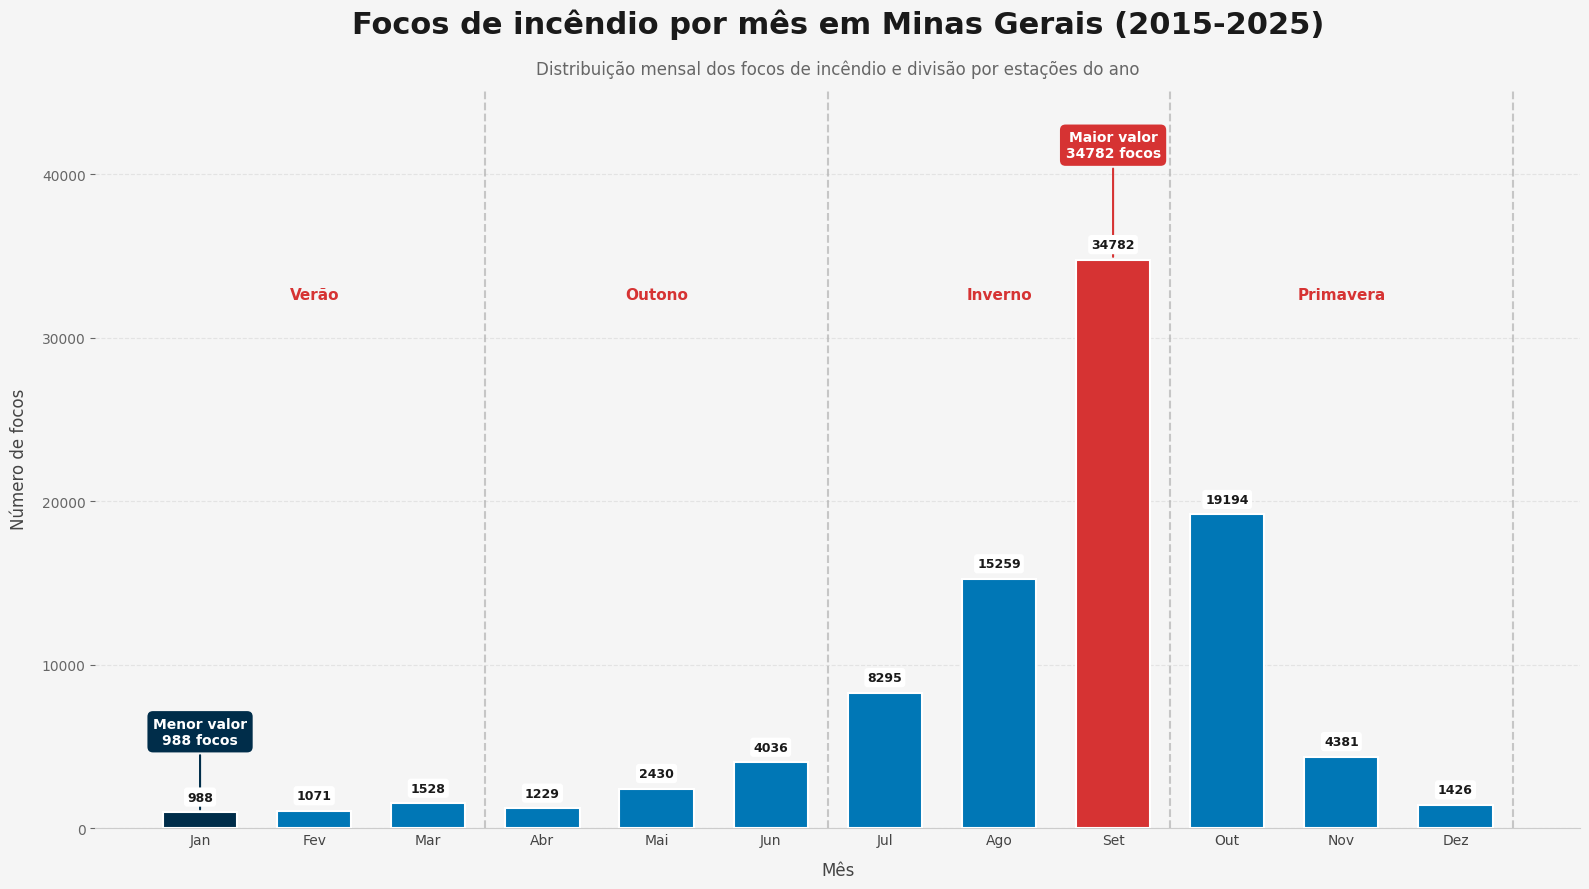

In [51]:
dataMes = pd.read_csv("../data/processed/focos_mg_mes_ref_2015-2025.csv", sep=",")

meses = dataMes["Mes"].values
focos = dataMes["Numero_Focos"].values

fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor("#f5f5f5")
ax.set_facecolor("#f5f5f5")

barras = ax.bar(
    meses,
    focos,
    width=0.65,
    color="#0077b6",
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

ax.set_ylim(0, max(focos) * 1.3)

ax.set_title(
    f"Focos de incêndio por mês em Minas Gerais (2015-2025)",
    fontsize=22,
    fontweight="bold",
    color="#1a1a1a",
    pad=40
)

ax.text(
    0.5, 1.02,
    "Distribuição mensal dos focos de incêndio e divisão por estações do ano",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#666"
)

ax.grid(True, axis="y", linestyle="--", alpha=0.25, zorder=0)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(axis="x", labelsize=10, length=0, colors="#444")
ax.tick_params(axis="y", labelsize=10, colors="#666")

ymax = max(focos)

for mes, value in zip(meses, focos):
    ax.text(
        mes,
        value + ymax * 0.015,
        f"{value}",
        fontsize=9,
        ha="center",
        va="bottom",
        color="#1a1a1a",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="none"
        ),
        zorder=5
    )

for x in [2.5, 5.5, 8.5, 11.5]:
    ax.axvline(x=x, linestyle="--", color="#999999", alpha=0.5, zorder=1)

y_estacao = ymax * 0.93

ax.text(1, y_estacao, "Verão", ha="center", fontsize=11, color="#d63333", fontweight="bold")
ax.text(4, y_estacao, "Outono", ha="center", fontsize=11, color="#d63333", fontweight="bold")
ax.text(7, y_estacao, "Inverno", ha="center", fontsize=11, color="#d63333", fontweight="bold")
ax.text(10, y_estacao, "Primavera", ha="center", fontsize=11, color="#d63333", fontweight="bold")

idx_max = np.argmax(focos)
idx_min = np.argmin(focos)

ax.bar(meses[idx_max], focos[idx_max], width=0.65, color="#d63333", edgecolor="white", linewidth=1.5, zorder=4)
ax.bar(meses[idx_min], focos[idx_min], width=0.65, color="#002d4a", edgecolor="white", linewidth=1.5, zorder=4)

ax.annotate(
    f"Maior valor\n{focos[idx_max]} focos",
    xy=(meses[idx_max], focos[idx_max]),
    xytext=(meses[idx_max], focos[idx_max] + ymax * 0.18),
    ha="center",
    fontsize=10,
    color="white",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="#d63333", ec="none"),
    arrowprops=dict(arrowstyle="-", color="#d63333", lw=1.5)
)

ax.annotate(
    f"Menor valor\n{focos[idx_min]} focos",
    xy=(meses[idx_min], focos[idx_min]),
    xytext=(meses[idx_min], focos[idx_min] + ymax * 0.12),
    ha="center",
    fontsize=10,
    color="white",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="#002d4a", ec="none"),
    arrowprops=dict(arrowstyle="-", color="#002d4a", lw=1.5)
)

ax.set_xlabel("Mês", fontsize=12, color="#444", labelpad=10)
ax.set_ylabel("Número de focos", fontsize=12, color="#444", labelpad=10)

plt.tight_layout()
plt.show()

In [29]:
dataMunicipiosMG = datamg["municipio"].value_counts().reset_index()
dataMunicipiosMG.columns = ["Municipio", "Numero_Focos"]

dataMunicipiosMG = dataMunicipiosMG.sort_values("Numero_Focos", ascending=False)

dataMunicipiosMG.to_csv("../data/processed/focos_mg_municipios_ref_2015-2025.csv", sep=",")

dataMunicipiosMG.head(850)

,Municipio,Numero_Focos
0,PARACATU,1727
1,JOÃO PINHEIRO,1383
2,LASSANCE,1342
3,UBERABA,1267
4,UNAÍ,1103
...,...,...
842,PASSABÉM,2
843,IBITIÚRA DE MINAS,1
844,SÃO JOSÉ DO MANTIMENTO,1
845,ROCHEDO DE MINAS,1


## Ranking das cidades com maior incidência de focos de incêncio

In [28]:
dataMunicipiosMG.head(10)

,Municipio,Numero_Focos
0,PARACATU,1727
1,JOÃO PINHEIRO,1383
2,LASSANCE,1342
3,UBERABA,1267
4,UNAÍ,1103
5,DIAMANTINA,1053
6,UBERLÂNDIA,1026
7,ARINOS,924
8,BURITIZEIRO,885
9,JAÍBA,879


In [52]:
ranking = dataMunicipiosMG.head(10)

In [ ]:
ranking.to_csv("../data/processed/focos_mg_top10_municipios_ref_2015-2025.csv", sep=",", index=False)

## Análise nas 10 maiores cidades de Minas Gerais

### Ranking das 10 maiores cidades de Minas Gerais em população (Estimativa 2025):
- Belo Horizonte: ~2.415.872 habitantes
- Uberlândia: ~761.835 habitantes
- Contagem: ~651.718 habitantes
- Juiz de Fora: ~567.730 habitantes
- Montes Claros: ~437.601 habitantes
- Betim: ~431.433 habitantes
- Uberaba: ~356.781 habitantes
- Ribeirão das Neves: ~346.971 habitantes
- Governador Valadares: ~266.561 habitantes
- Divinópolis: ~243.583 habitantes

Serão feiras analises com relação á taxa de variação anual do numero de focos

In [88]:
def separarPorMunicipioPorAno(municipio, dataset_path):

    #Separando por municipio
    dataset = pd.read_csv(dataset_path, sep=",")
    dataset = dataset[dataset["municipio"] == municipio.upper()].reset_index()

    #Separando por ano
    dataset["data_pas"] = pd.to_datetime(dataset["data_pas"])
    dataset["Ano"] = dataset["data_pas"].dt.year
    dataset = dataset.drop(["index", "data_pas", "municipio"], axis=1)
    dataset = dataset.groupby("Ano").size().reset_index(name="Numero_Focos")

    dataset["Taxa de Variação Anual (%)"] = (dataset["Numero_Focos"].pct_change() * 100).round(2)

    return dataset

In [91]:
dataset = separarPorMunicipioPorAno("Lavras", "../data/processed/focos_mg_ref_2015-2025.csv")
dataset.head()

,Ano,Numero_Focos,Taxa de Variação Anual (%)
0,2015,4,NaN
1,2016,8,100.00
2,2017,45,462.50
3,2018,3,-93.33
4,2019,7,133.33


In [8]:
#criação do grafico de serie historica para Belo Horizonte
def graficoSerieHistorica(municipio):

    def separarPorMunicipioPorAno(municipio, dataset_path):

    #Separando por municipio
        dataset = pd.read_csv(dataset_path, sep=",")
        dataset = dataset[dataset["municipio"] == municipio.upper()].reset_index()

        #Separando por ano
        dataset["data_pas"] = pd.to_datetime(dataset["data_pas"])
        dataset["Ano"] = dataset["data_pas"].dt.year
        dataset = dataset.drop(["index", "data_pas", "municipio"], axis=1)
        dataset = dataset.groupby("Ano").size().reset_index(name="Numero_Focos")

        dataset["Taxa de Variação Anual (%)"] = (dataset["Numero_Focos"].pct_change() * 100).round(2)

        return dataset
    
    dataset = separarPorMunicipioPorAno(municipio, "../data/processed/focos_mg_ref_2015-2025.csv")

    anos = dataset["Ano"].values
    taxa = dataset["Taxa de Variação Anual (%)"].values

    # Criar figura
    fig, ax = plt.subplots(figsize=(16, 9))

    # Fundo
    bg = "#ffffff"
    fig.patch.set_facecolor(bg)
    ax.set_facecolor(bg)

    # Linha principal
    ax.plot(
        anos,
        taxa,
        color="#1f4e8c",
        linewidth=3,
        marker="o",
        markersize=7,
        zorder=3
    )

    # Linha horizontal no zero (IMPORTANTÍSSIMO)
    ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

    # Remover bordas
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#bfc5cc")

    # Título
    ax.set_title(
        f"Taxa de Variação Anual dos Focos de Incêndio ({municipio.capitalize()})",
        fontsize=22,
        fontweight="bold",
        color="#000000",
        pad=40
    )

    # Eixo X
    ax.set_xticks(anos)
    ax.set_xticklabels(anos, fontsize=11)
    ax.tick_params(axis="x", length=0)

    # Eixo Y
    ax.set_ylabel("%", fontsize=12)

    # Destacar pontos positivos e negativos
    for i in range(len(anos)):
        if np.isnan(taxa[i]):
            continue

        if taxa[i] > 0:
            cor = "#1f8c3a"
        else:
            cor = "#8c1f1f"

        ax.scatter(anos[i], taxa[i], color=cor, s=80, zorder=5)

        ax.text(
            anos[i],
            taxa[i] + (6),
            f"{taxa[i]:.1f}%",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor
        )

    # Destaque do maior crescimento
    idx_max = np.nanargmax(taxa)
    ax.annotate(
        f"{taxa[idx_max]:.1f}%\nmaior alta",
        xy=(anos[idx_max], taxa[idx_max]),
        xytext=(anos[idx_max]-1.5, taxa[idx_max]+10),
        bbox=dict(boxstyle="round,pad=0.5", fc="#eaf2ff"),
        arrowprops=dict(arrowstyle="-"),
        fontsize=11,
        color="#1f8c3a"
    )

    # Destaque da maior queda
    idx_min = np.nanargmin(taxa)
    ax.annotate(
        f"{taxa[idx_min]:.1f}%\nmaior queda",
        xy=(anos[idx_min], taxa[idx_min]),
        xytext=(anos[idx_min]-1.5, taxa[idx_min]-12),
        bbox=dict(boxstyle="round,pad=0.5", fc="#ffeaea"),
        arrowprops=dict(arrowstyle="-"),
        fontsize=11,
        color="#8c1f1f"
    )

    # Rodapé
    fig.text(
        0.02, 0.02,
        "Fonte: INPE | Indicador: Taxa de variação anual",
        fontsize=10,
        color="#666"
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()



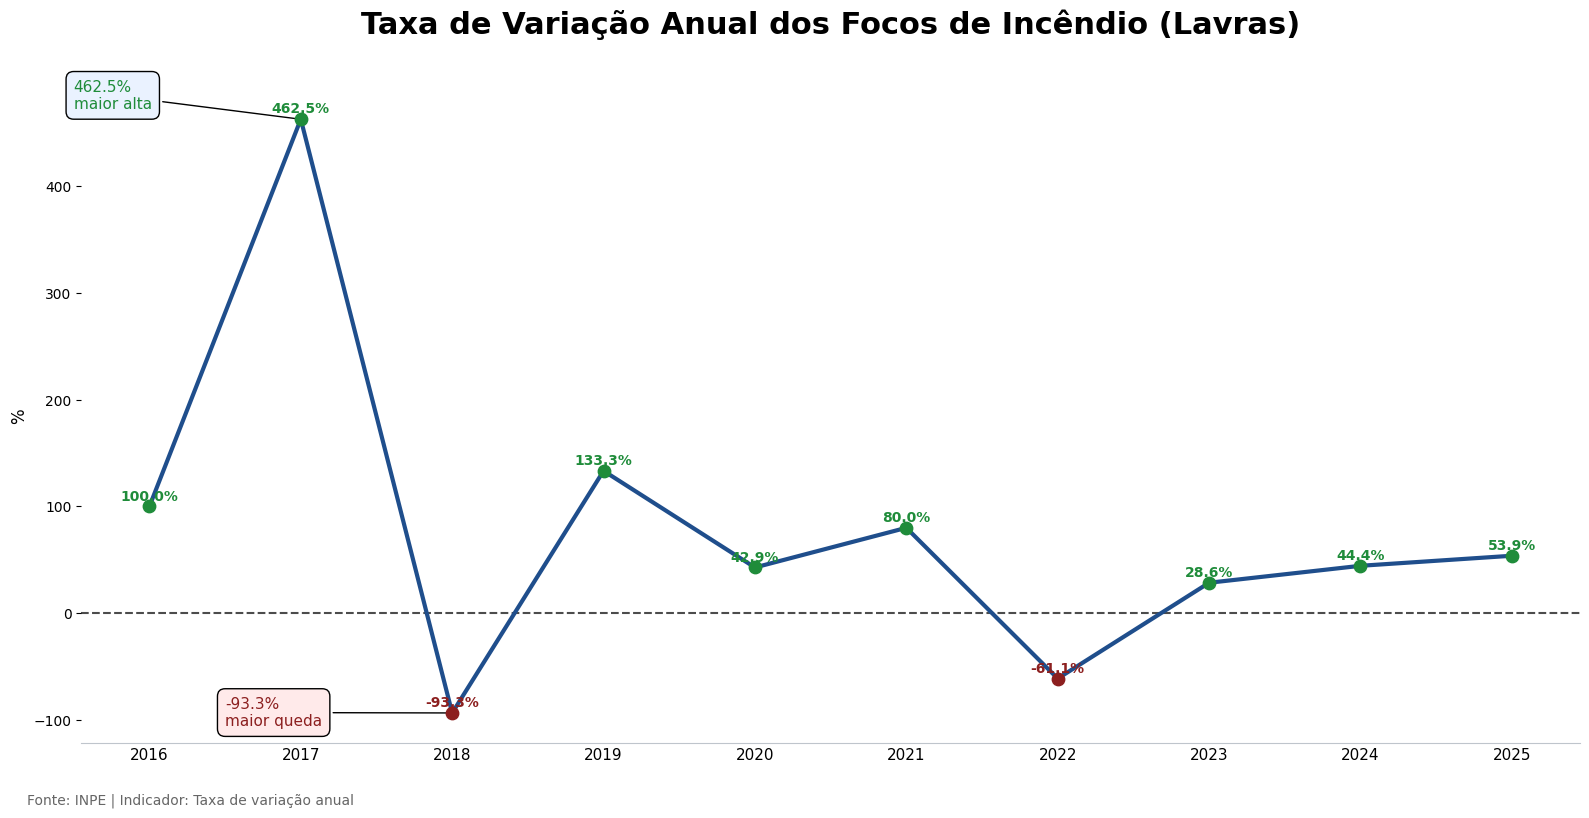

In [9]:
graficoSerieHistorica("Lavras")

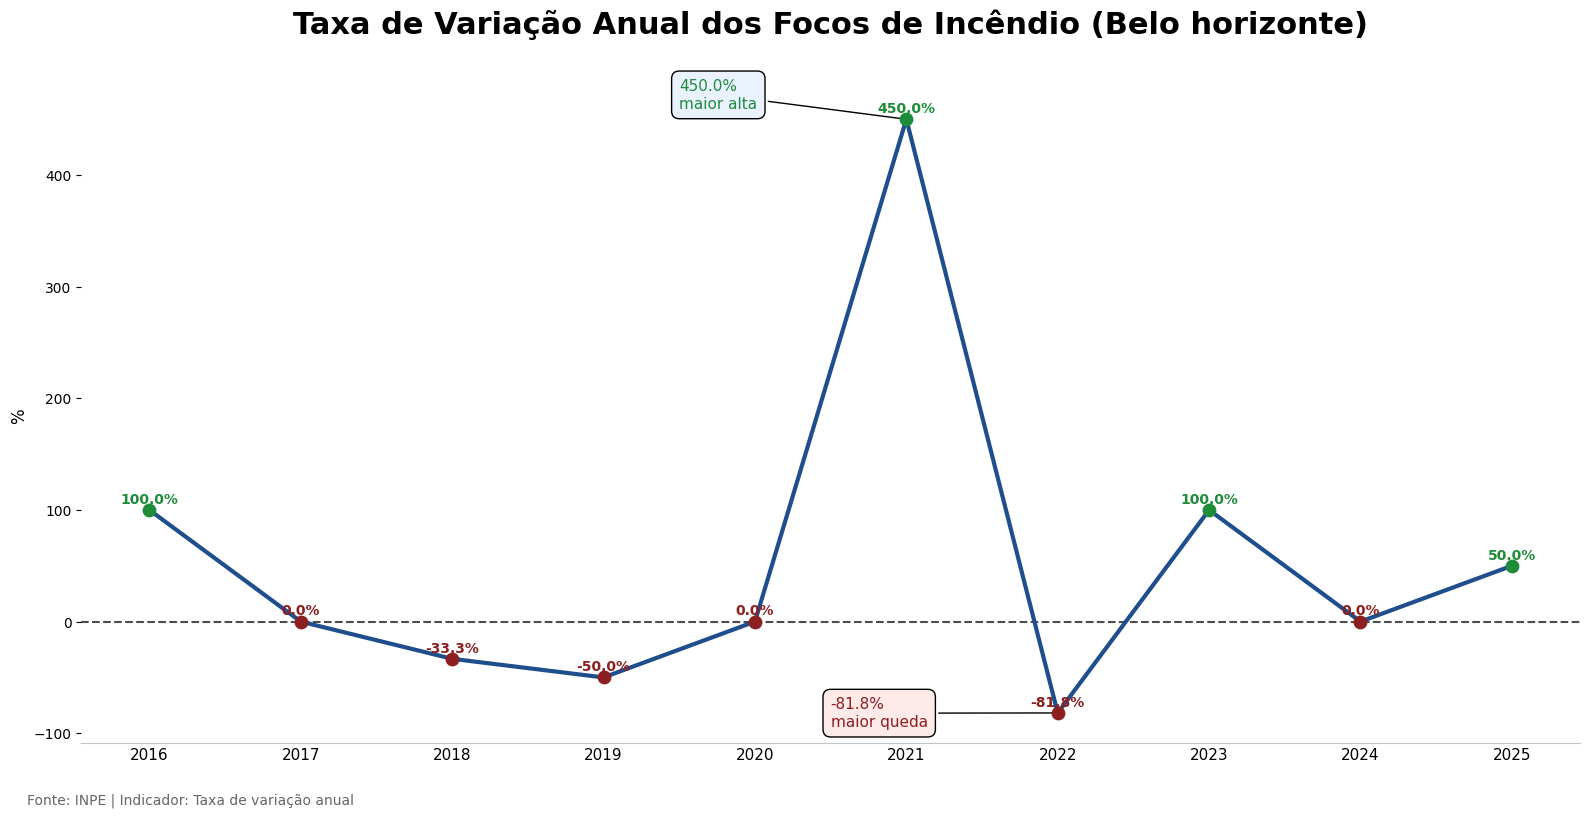

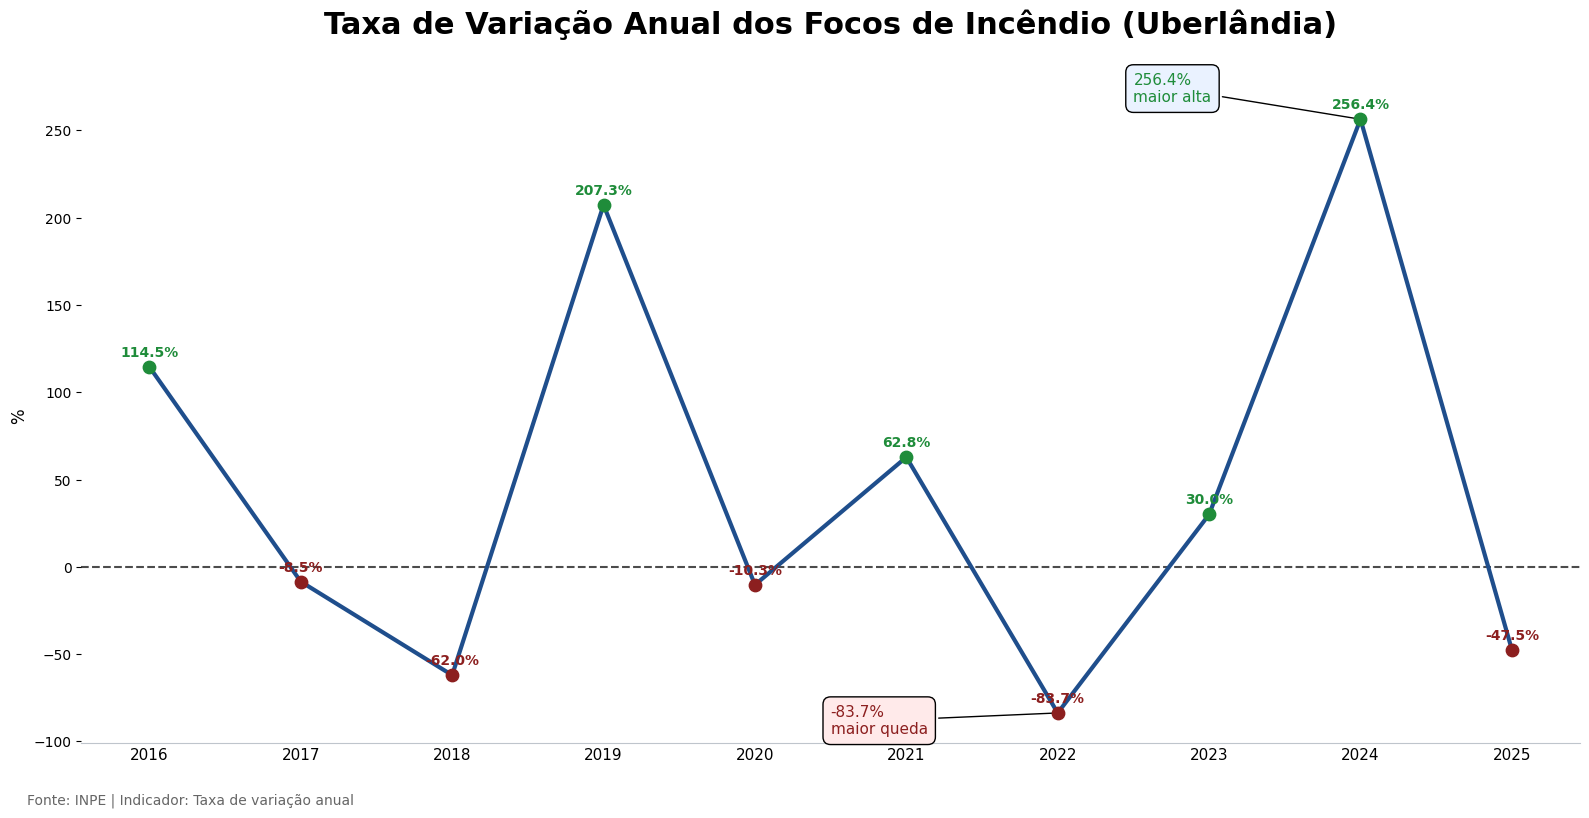

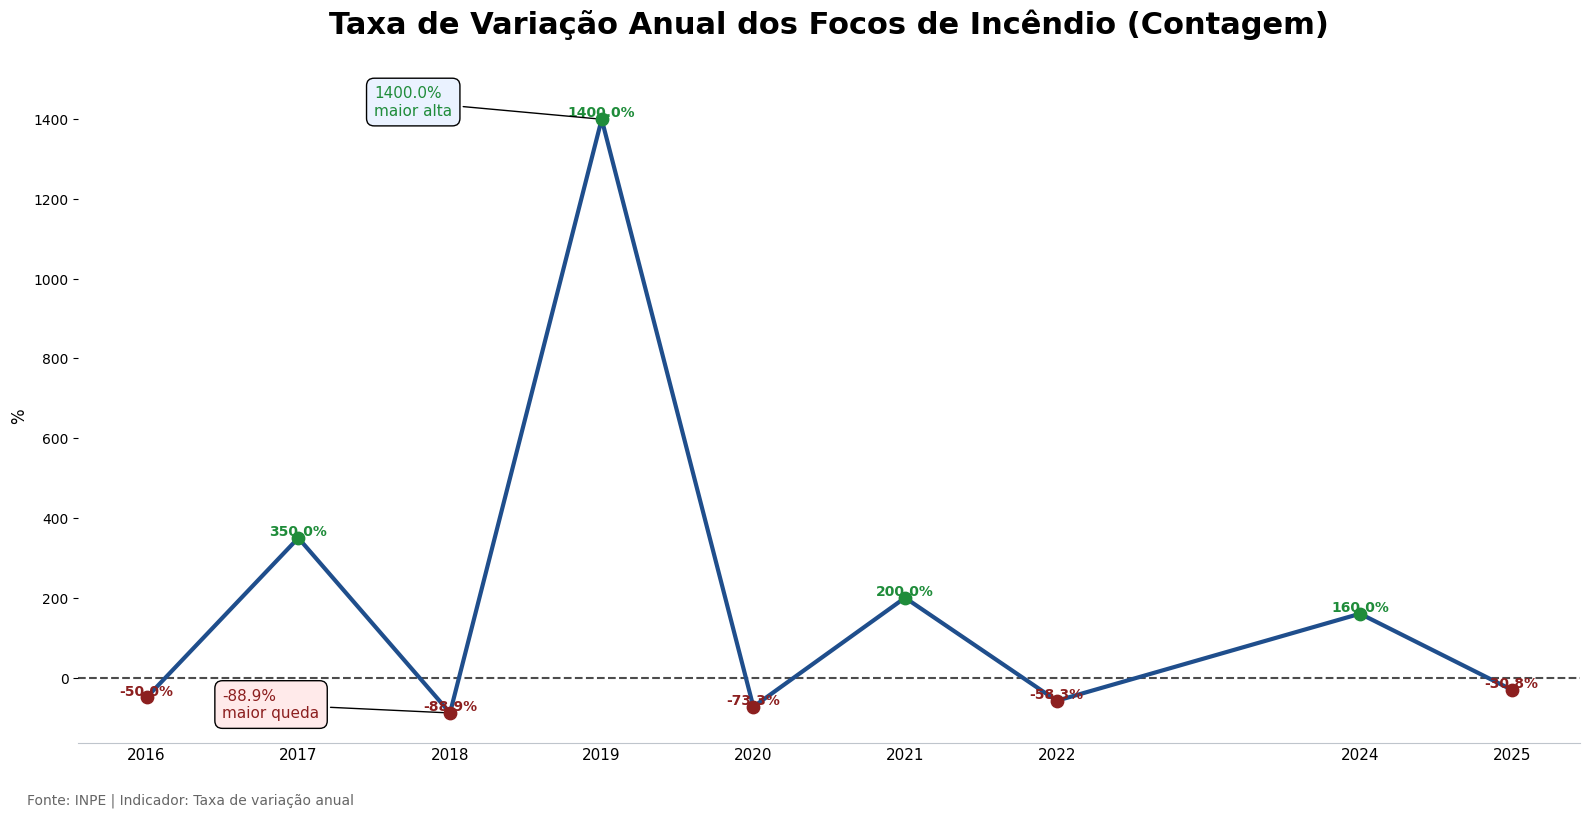

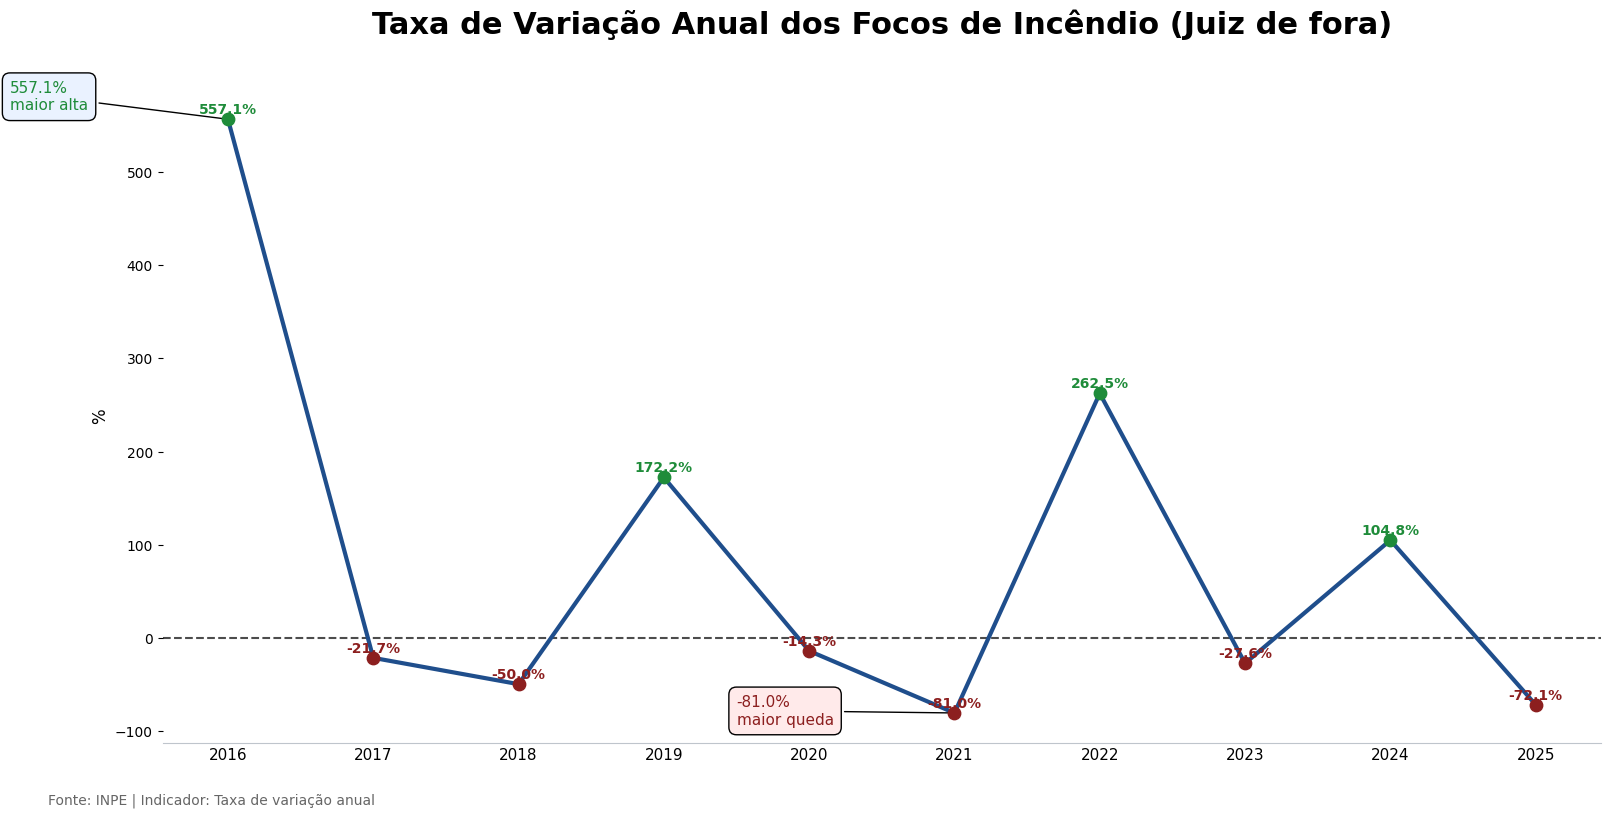

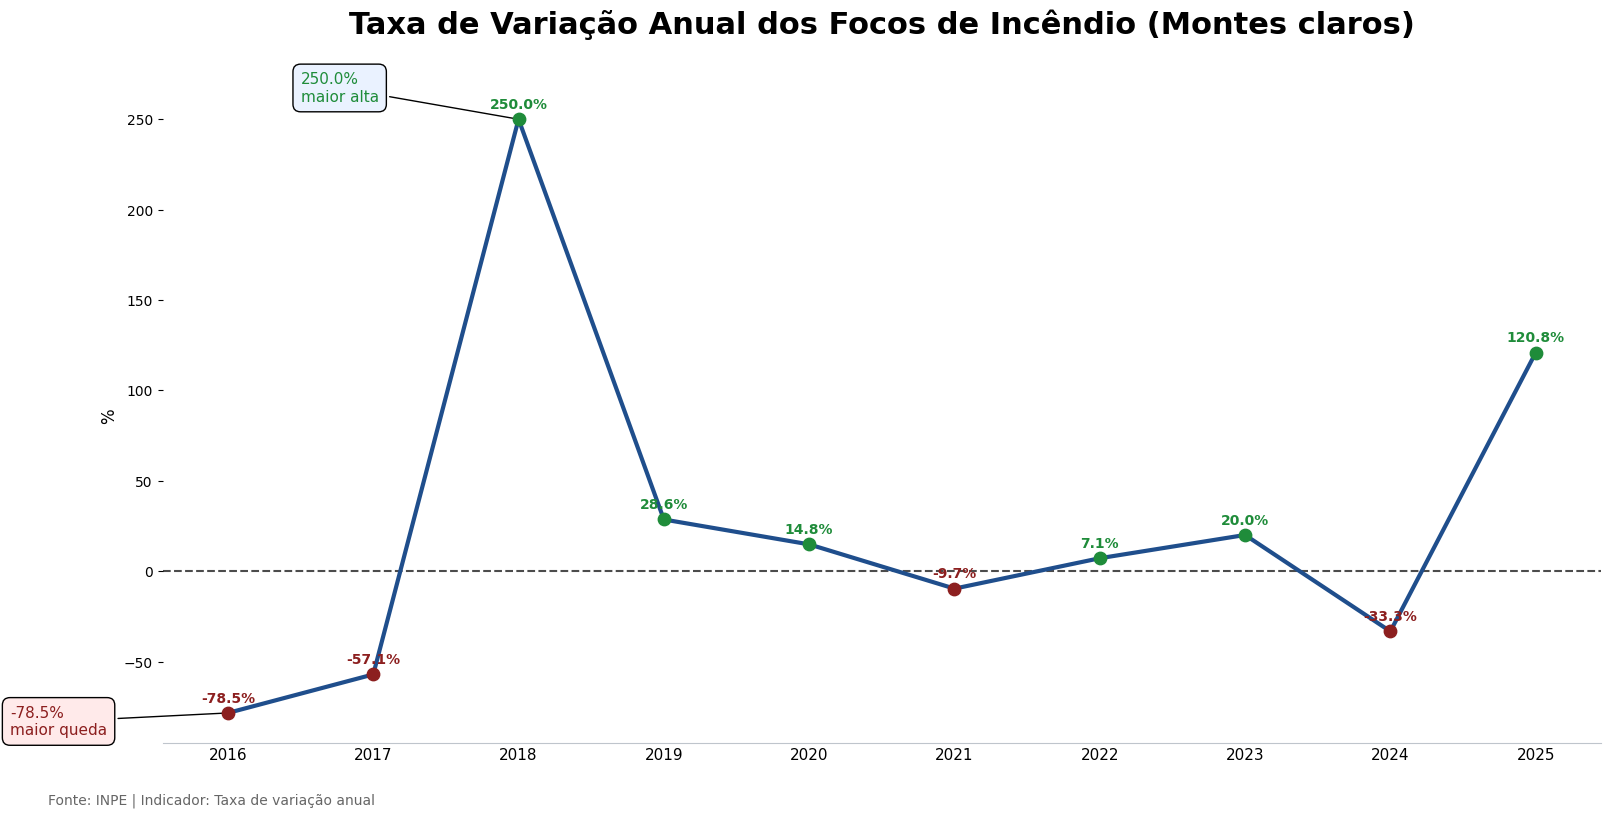

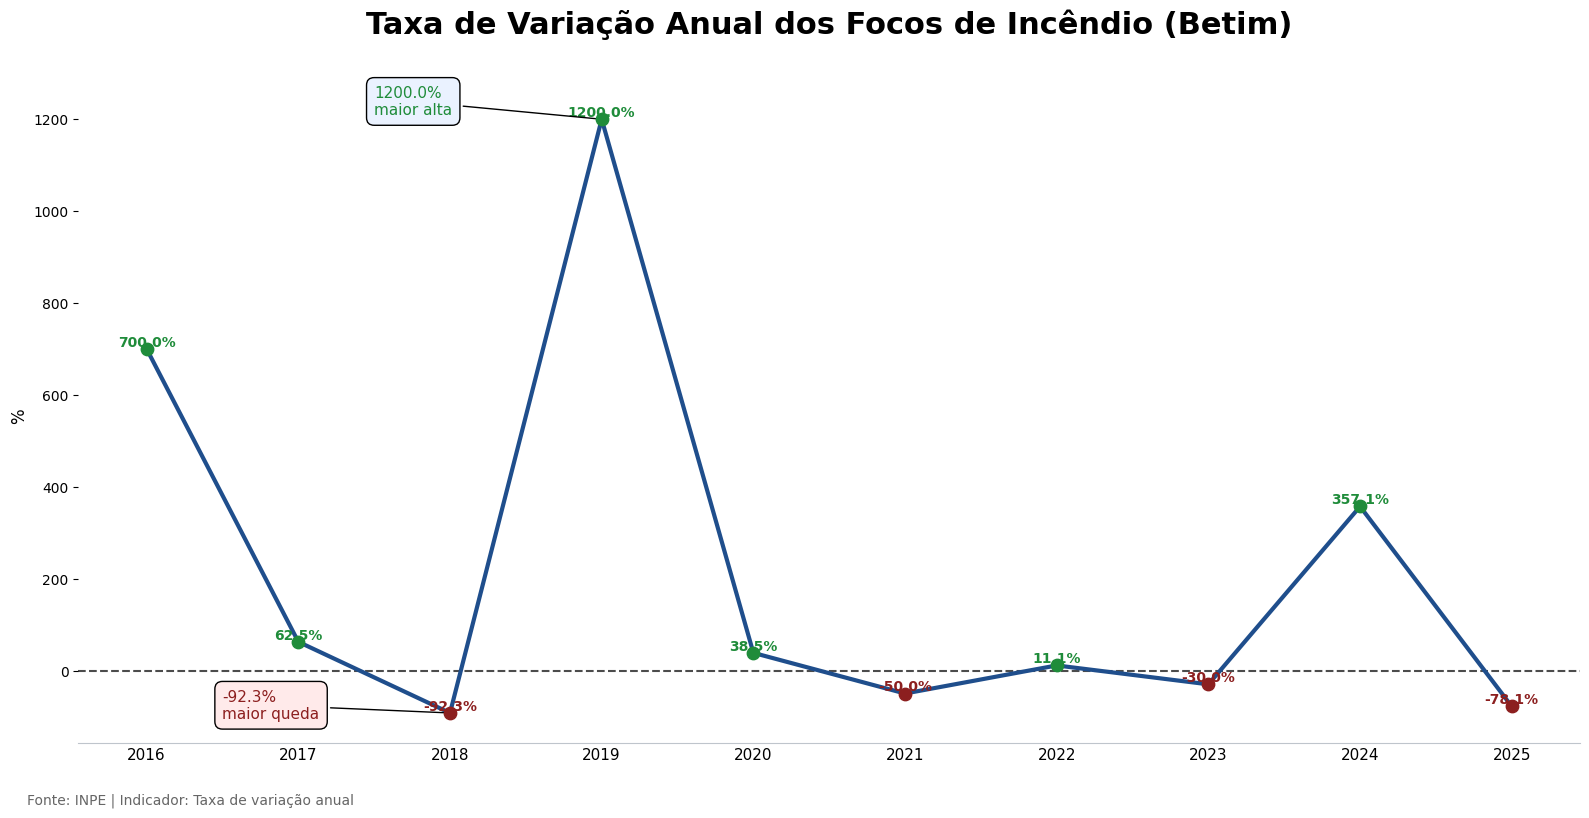

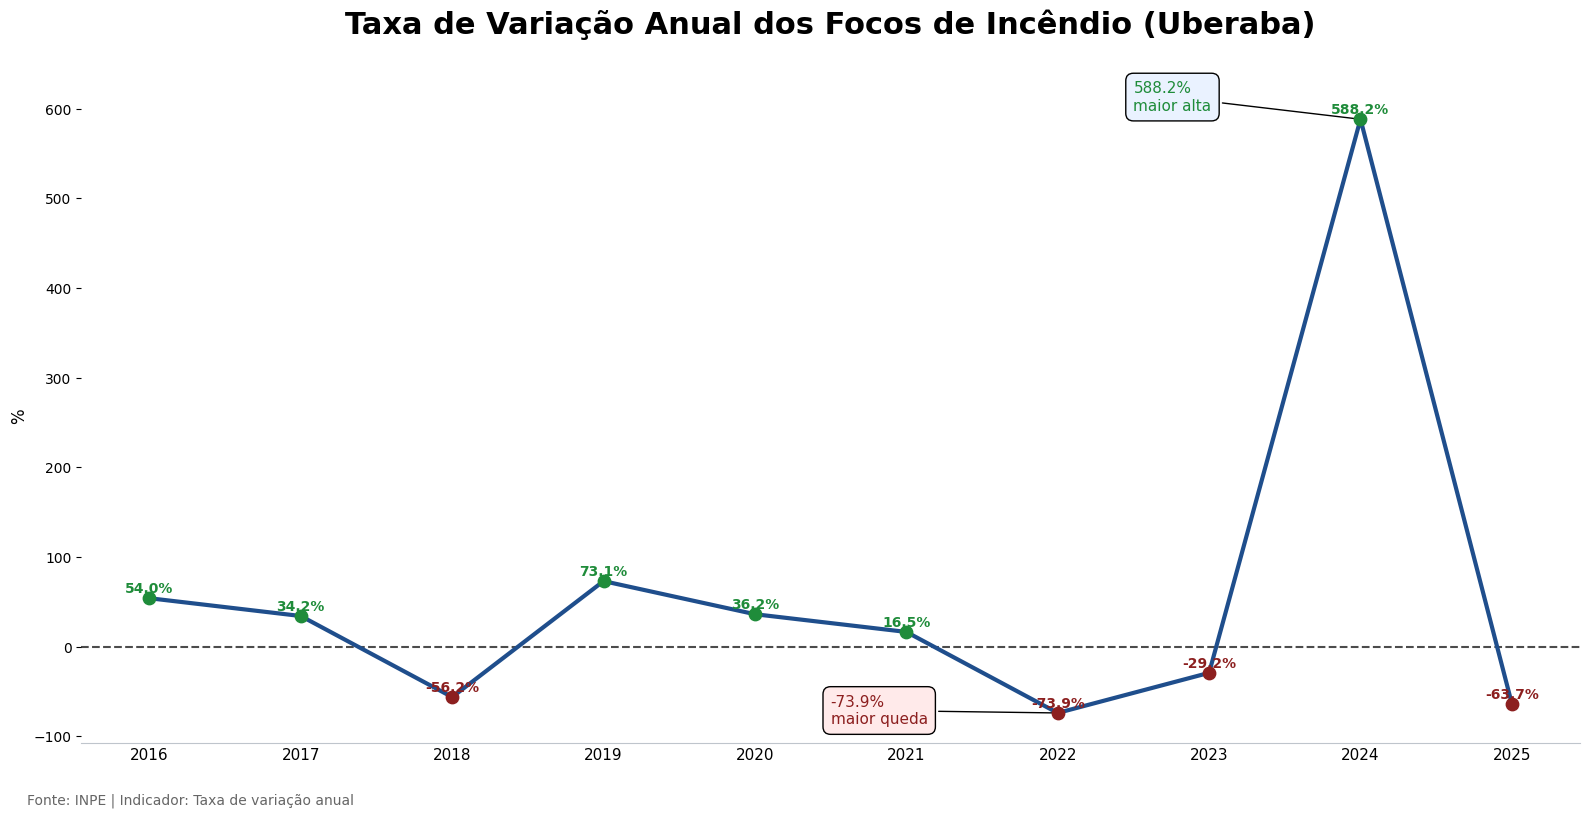

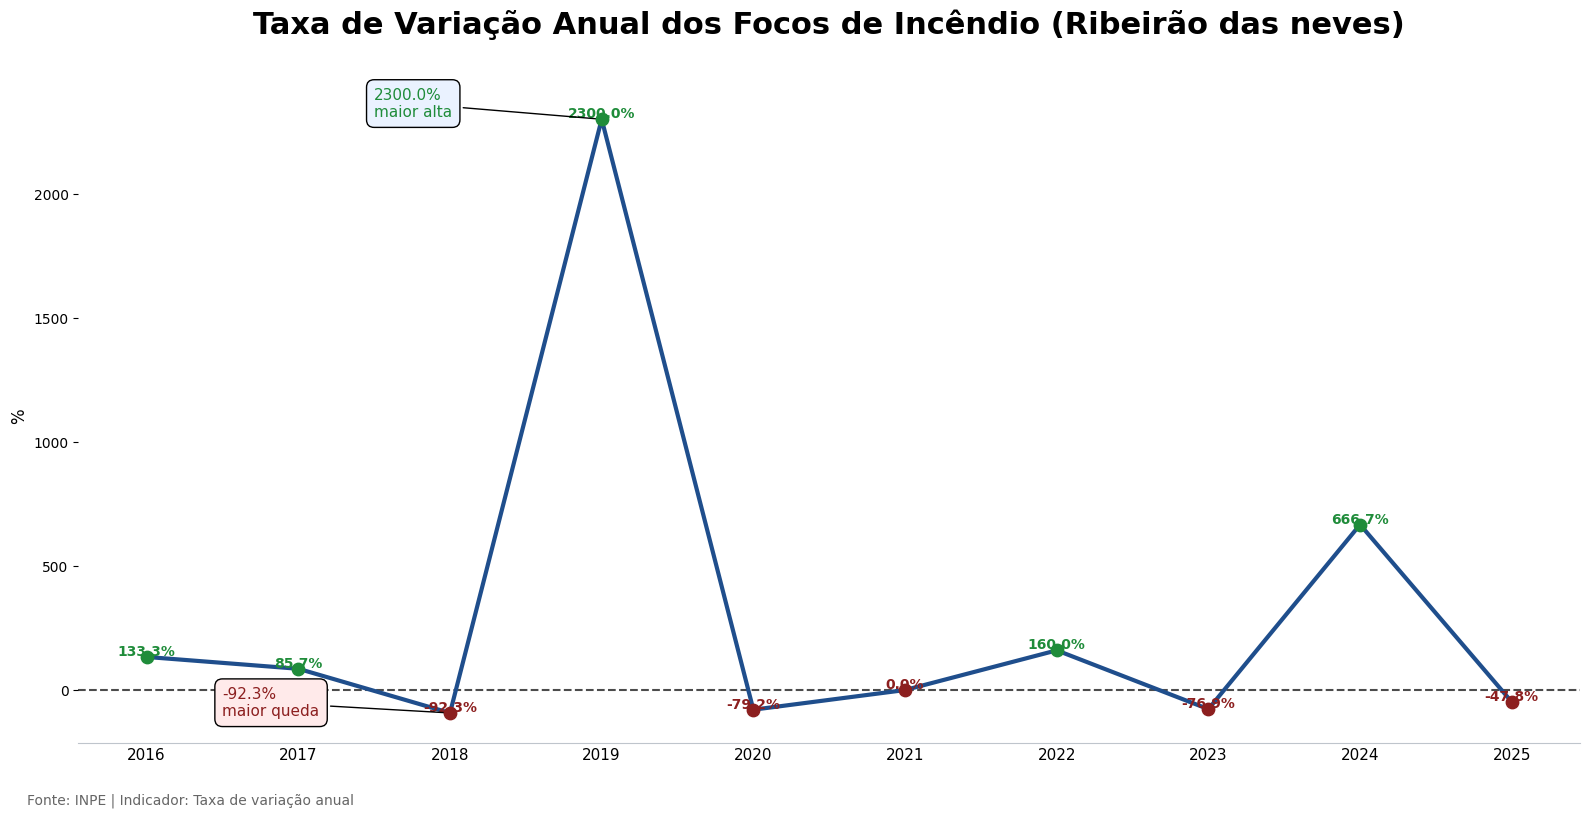

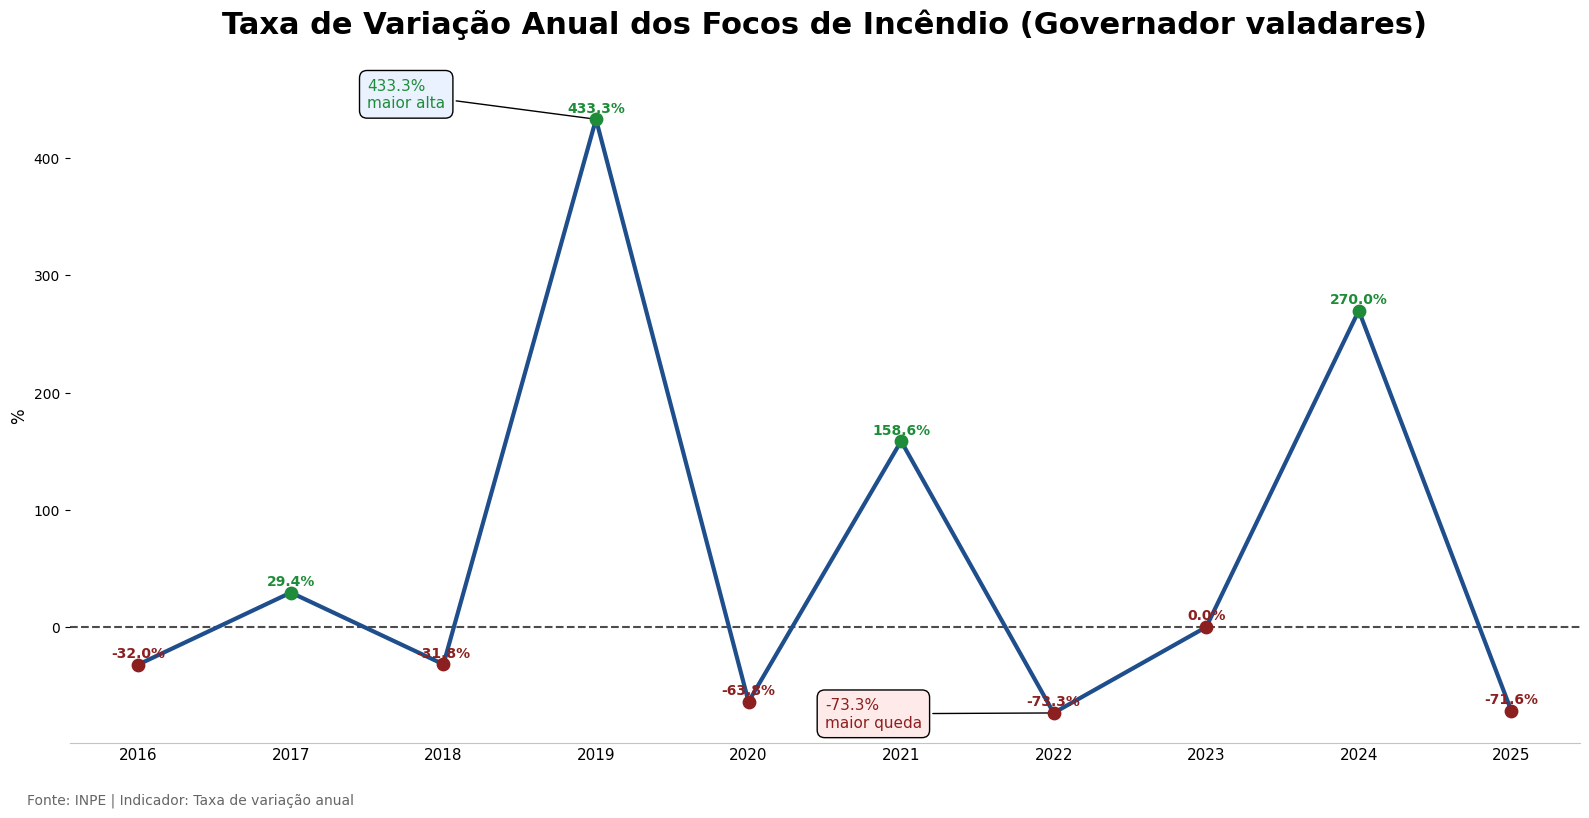

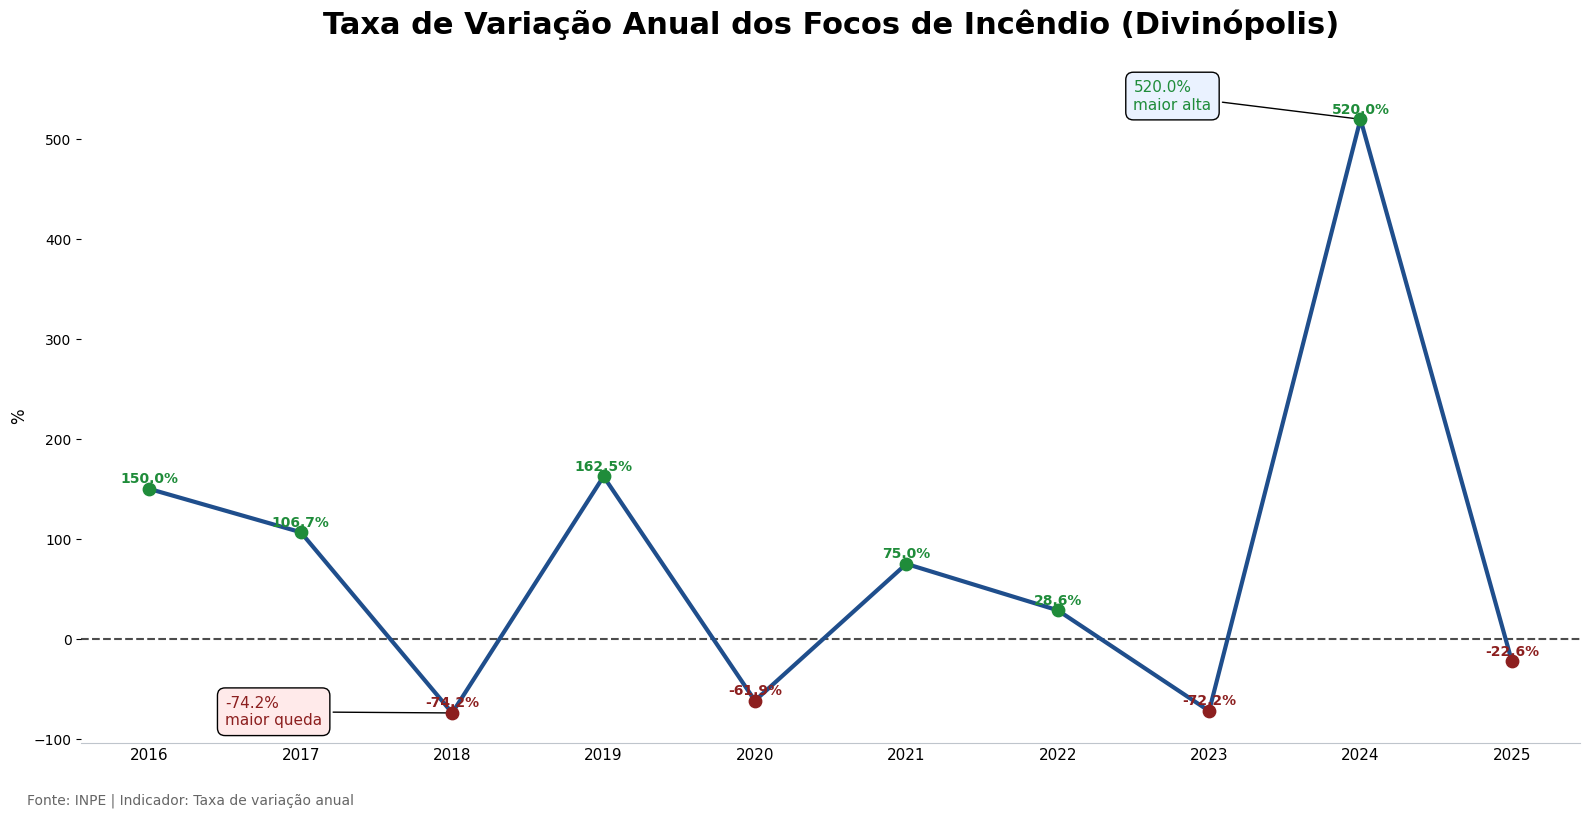

In [10]:
#lista das maiores cidades de Minas Gerais
maioresCidades = ["Belo Horizonte", "Uberlândia", "Contagem", "Juiz de Fora", "Montes Claros", "Betim", "Uberaba", "Ribeirão das Neves", "Governador Valadares", "Divinópolis"]

for cidade in maioresCidades:
    graficoSerieHistorica(cidade)

FUNÇÃO QUE DÁ O NUMERO DE FOCOS POR MUNICÍPIO

In [32]:
def focos_municipio(municipio:str, datasetpath: str):
    try:
        if not isinstance(municipio, str):
            raise ValueError("O nome do município deve ser uma string.")
        
        dataset = pd.read_csv(datasetpath, sep=",")

        dataset = dataset[dataset["Municipio"] == municipio.upper()]
        if dataset.empty:
            raise ValueError(f"Município '{municipio}' não encontrado no dataset.")
        
        numero_focos = dataset.iloc[0]["Numero_Focos"]

        return numero_focos
    except ValueError as e:
        print(e)
        return None

focos = focos_municipio("divinópolis", "../data/processed/focos_mg_municipios_ref_2015-2025.csv")

if focos is not None:
    print(focos)

181


In [4]:
def focos_mes_municipio(municipio: str, datasetPath: str):

    dataset = pd.read_csv(datasetPath, sep=",")

    try:

        dataset = dataset[dataset["municipio"] == municipio.upper()]

        if(dataset.empty):
            raise ValueError(f"Município '{municipio}' não encontrado no dataset.")
        
        dataset["data_pas"] = pd.to_datetime(dataset["data_pas"])

        dataMunicipio = dataset.groupby(dataset["data_pas"].dt.month).size()

        dataMunicipio = dataMunicipio.reindex(range(1, 13), fill_value=0)

        meses = {
            1: "Jan",
            2: "Fev",
            3: "Mar",
            4: "Abr",
            5: "Mai",
            6: "Jun",
            7: "Jul",
            8: "Ago",
            9: "Set",
            10: "Out",
            11: "Nov",
            12: "Dez"
        }

        dataMunicipio = dataMunicipio.reset_index()
        dataMunicipio.columns = ["mes_num", "Focos"]
        dataMunicipio["mes"] = dataMunicipio["mes_num"].map(meses)

        return dataMunicipio
    
    except ValueError:
        print(f"Município '{municipio}' não encontrado no dataset.")
        return
    
dfDiv = focos_mes_municipio("divinópolis", "../data/processed/focos_mg_ref_2015-2025.csv")

if dfDiv is not None:
    display(dfDiv.head(12))
    

,mes_num,Focos,mes
0,1,0,Jan
1,2,0,Fev
2,3,2,Mar
3,4,3,Abr
4,5,5,Mai
5,6,6,Jun
6,7,24,Jul
7,8,46,Ago
8,9,89,Set
9,10,4,Out


APLICAÇÃO DA FUNÇÃO QUE MOSRTA O NÚMERO DE FOCOS POR MÊS EM UM MUNICÍPIO

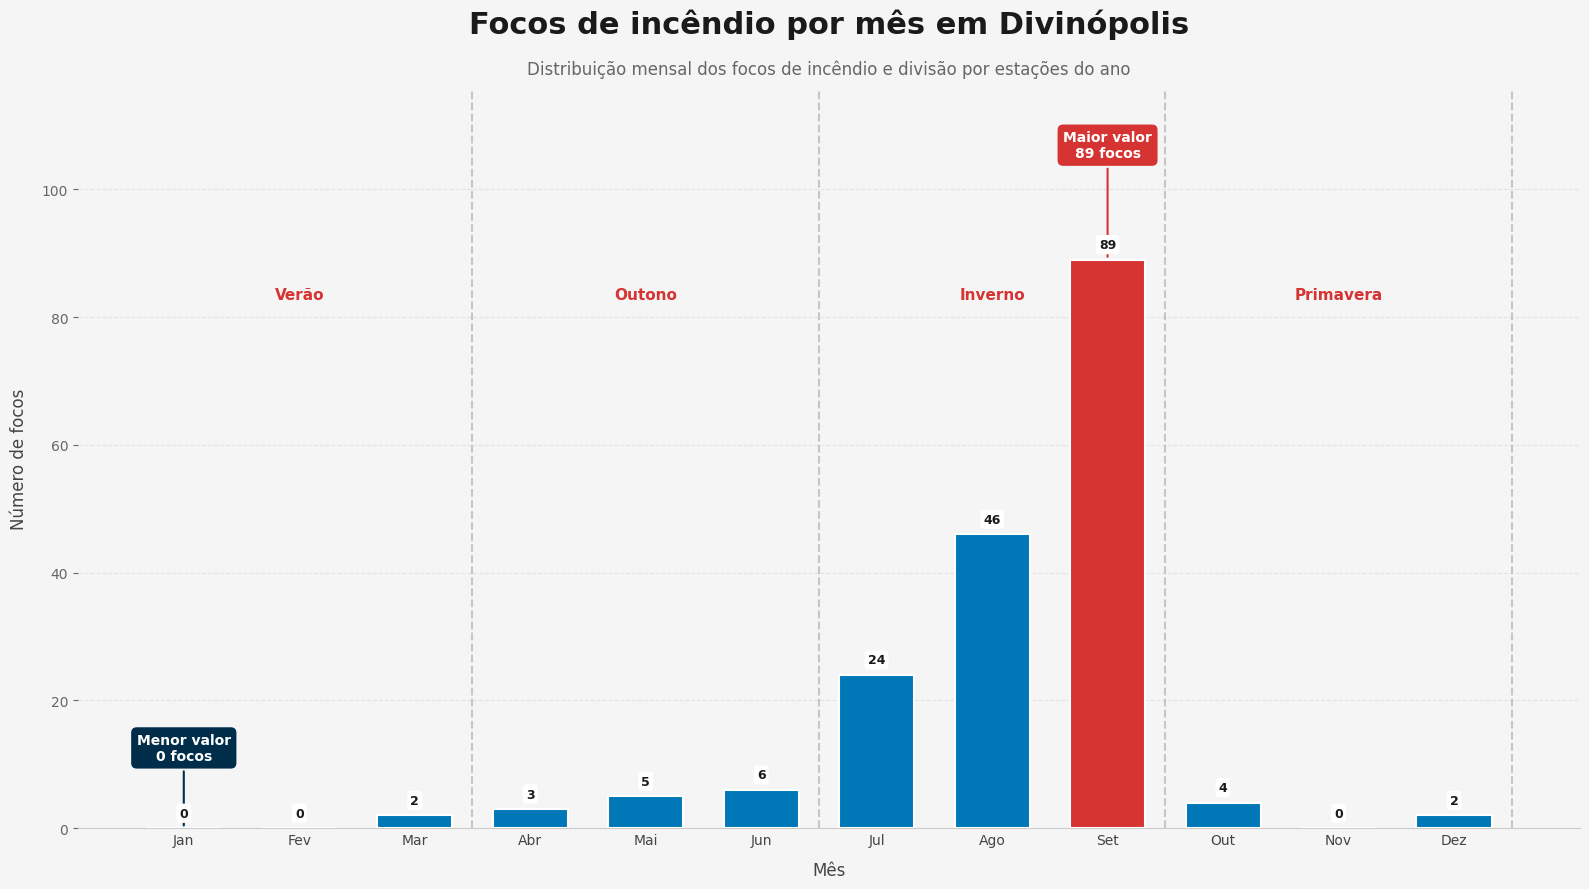

In [5]:
municipio = input().upper()
dataMunicipiosMG = pd.read_csv("../data/processed/focos_mg_municipios_ref_2015-2025.csv", sep=",")
listaMunicipios = list(dataMunicipiosMG["Municipio"].unique())

if municipio in listaMunicipios:

    dfMunicipio = focos_mes_municipio(municipio, "../data/processed/focos_mg_ref_2015-2025.csv")

    meses = dfMunicipio["mes"].values
    focos = dfMunicipio["Focos"].values

    fig, ax = plt.subplots(figsize=(16, 9))
    fig.patch.set_facecolor("#f5f5f5")
    ax.set_facecolor("#f5f5f5")

    barras = ax.bar(
        meses,
        focos,
        width=0.65,
        color="#0077b6",
        edgecolor="white",
        linewidth=1.5,
        zorder=3
    )

    ax.set_ylim(0, max(focos) * 1.3)

    ax.set_title(
        f"Focos de incêndio por mês em {municipio.capitalize()}",
        fontsize=22,
        fontweight="bold",
        color="#1a1a1a",
        pad=40
    )

    ax.text(
        0.5, 1.02,
        "Distribuição mensal dos focos de incêndio e divisão por estações do ano",
        transform=ax.transAxes,
        ha="center",
        fontsize=12,
        color="#666"
    )

    ax.grid(True, axis="y", linestyle="--", alpha=0.25, zorder=0)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(axis="x", labelsize=10, length=0, colors="#444")
    ax.tick_params(axis="y", labelsize=10, colors="#666")

    ymax = max(focos)

    for mes, value in zip(meses, focos):
        ax.text(
            mes,
            value + ymax * 0.015,
            f"{value}",
            fontsize=9,
            ha="center",
            va="bottom",
            color="#1a1a1a",
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec="none"
            ),
            zorder=5
        )

    for x in [2.5, 5.5, 8.5, 11.5]:
        ax.axvline(x=x, linestyle="--", color="#999999", alpha=0.5, zorder=1)

    y_estacao = ymax * 0.93

    ax.text(1, y_estacao, "Verão", ha="center", fontsize=11, color="#d63333", fontweight="bold")
    ax.text(4, y_estacao, "Outono", ha="center", fontsize=11, color="#d63333", fontweight="bold")
    ax.text(7, y_estacao, "Inverno", ha="center", fontsize=11, color="#d63333", fontweight="bold")
    ax.text(10, y_estacao, "Primavera", ha="center", fontsize=11, color="#d63333", fontweight="bold")

    idx_max = np.argmax(focos)
    idx_min = np.argmin(focos)

    ax.bar(meses[idx_max], focos[idx_max], width=0.65, color="#d63333", edgecolor="white", linewidth=1.5, zorder=4)
    ax.bar(meses[idx_min], focos[idx_min], width=0.65, color="#002d4a", edgecolor="white", linewidth=1.5, zorder=4)

    ax.annotate(
        f"Maior valor\n{focos[idx_max]} focos",
        xy=(meses[idx_max], focos[idx_max]),
        xytext=(meses[idx_max], focos[idx_max] + ymax * 0.18),
        ha="center",
        fontsize=10,
        color="white",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="#d63333", ec="none"),
        arrowprops=dict(arrowstyle="-", color="#d63333", lw=1.5)
    )

    ax.annotate(
        f"Menor valor\n{focos[idx_min]} focos",
        xy=(meses[idx_min], focos[idx_min]),
        xytext=(meses[idx_min], focos[idx_min] + ymax * 0.12),
        ha="center",
        fontsize=10,
        color="white",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="#002d4a", ec="none"),
        arrowprops=dict(arrowstyle="-", color="#002d4a", lw=1.5)
    )

    ax.set_xlabel("Mês", fontsize=12, color="#444", labelpad=10)
    ax.set_ylabel("Número de focos", fontsize=12, color="#444", labelpad=10)

    plt.tight_layout()
    plt.show()

In [30]:
PATH1 = "../data/processed/focos_mg_ref_2015-2025.csv"
PATH2 = "../data/processed/focos_mg_municipios_ref_2015-2025.csv"

df = pd.read_csv(PATH1, sep = ",", index_col=0)
data_municipios = pd.read_csv(PATH2, sep=",", index_col=0)



coords = df.groupby("municipio")[["lat", "lon"]].mean().reset_index()

data_municipios = data_municipios.merge(coords, left_on="Municipio", right_on="municipio", how="left")
data_municipios = data_municipios.drop(["municipio"], axis=1)

data_municipios.to_csv("../data/processed/focos_mg_municipios_ref_mapa.csv", sep=",")
data_municipios.head()

,Municipio,Numero_Focos,lat,lon
0,PARACATU,1727,-17.253227,-46.881372
1,JOÃO PINHEIRO,1383,-17.567416,-45.995193
2,LASSANCE,1342,-17.835112,-44.505908
3,UBERABA,1267,-19.672502,-47.959500
4,UNAÍ,1103,-16.407472,-46.808528


CRIAÇÃO DO MAPA DE CALOR

In [31]:
mapa = fl.Map(location=[-19.0, -44.0], zoom_start=6.5)
data = list(zip(data_municipios.lat, data_municipios.lon, data_municipios.Numero_Focos))
heatMap = HeatMap(data, radius=20, blur=20)
mapa.add_child(heatMap)
mapa.save("../maps/HeatMapMG.html")

CRIAÇÃO DE MAPA COM OS FOCOS DO ÚLTIMO ANO PARA CADA MUNICÍPIO 

In [36]:
def data_municipio(municipio: str, datasetPath: str):
    dataset = pd.read_csv(datasetPath, sep=",")
    dataset = dataset[dataset["municipio"] == municipio]

    dataset["data_pas"] = pd.to_datetime(dataset["data_pas"])
    
    dataset = dataset[dataset["data_pas"].dt.year == 2025]

    return dataset


In [4]:
dados_divinopolis = data_municipio("DIVINÓPOLIS", "../data/processed/focos_mg_ref_2015-2025.csv")
dados_divinopolis.head()

,Unnamed: 0,lat,lon,data_pas,municipio,bioma
1652,1652,-20.21016,-44.88184,2025-07-28 18:04:00,DIVINÓPOLIS,Cerrado
1726,1726,-19.93563,-44.89834,2025-07-31 18:24:00,DIVINÓPOLIS,Cerrado
1996,1996,-19.99867,-44.94572,2025-08-10 18:17:00,DIVINÓPOLIS,Cerrado
2079,2079,-20.20079,-44.80566,2025-08-12 17:56:00,DIVINÓPOLIS,Cerrado
2092,2092,-20.20213,-44.81517,2025-08-12 17:56:00,DIVINÓPOLIS,Cerrado


In [37]:
#criação de mapa de focos para o municipio no ultimo ano disponível
def mapa_focos_municipio(municipio, PATH):

    dados_municipio = data_municipio(municipio, PATH)
    mapa_municipio = fl.Map(location=[dados_municipio["lat"].mean(), dados_municipio["lon"].mean()], zoom_start=10)
    for _, row in dados_municipio.iterrows():
        fl.Marker(
            location=[row["lat"], row["lon"]], 
            popup=f"Data: {row['data_pas']}",
            icon=fl.Icon(icon="fire",color="red"),).add_to(mapa_municipio)
    mapa_municipio.save(f"../maps/mapa_focos_{municipio}.html")


In [38]:
municipio = input("Digite o nome do município para visualizar o mapa de focos de incêndio: ").upper()
PATH = "../data/processed/focos_mg_ref_2015-2025.csv"

mapa_focos_municipio(municipio, PATH)